# Logistic Regression for Anomaly Detection

This notebook implements Logistic Regression to identify anomalous users in a recommender system dataset.

### Pipeline Overview
1. Load and inspect data
2. Build per-user feature vectors (pivot to user × item rating matrix)
3. Reduce dimensionality with TruncatedSVD (handles sparsity well)
4. Train Logistic Regression with class balancing
5. Evaluate with AUC, Precision, Recall, F1
6. Generate and save anomaly scores for submission

## 1. Imports & Data Loading

In [ ]:
import os
from dotenv import load_dotenv

# Walk up directories until we find .env
_dir = os.getcwd()
while _dir != os.path.dirname(_dir):
    if os.path.exists(os.path.join(_dir, ".env")):
        PROJECT_ROOT = _dir
        break
    _dir = os.path.dirname(_dir)

load_dotenv(os.path.join(PROJECT_ROOT, ".env"))

ORIGINAL_MATS_DIR = os.path.join(PROJECT_ROOT, str(os.getenv("ORIGINAL_MATS_DIR")))
WEIGHTS_DIR_LARRY = os.path.join(PROJECT_ROOT, str(os.getenv("WEIGHTS_DIR_LARRY")))
GRAPHS_DIR_LARRY = os.path.join(PROJECT_ROOT, str(os.getenv("GRAPHS_DIR_LARRY")))
RESULTS_DIR_LARRY = os.path.join(PROJECT_ROOT, str(os.getenv("RESULTS_DIR_LARRY")))

NOTEBOOK_FOLDER = os.path.basename(os.getcwd())

WEIGHTS_DIR_LARRY = os.path.join(WEIGHTS_DIR_LARRY, NOTEBOOK_FOLDER)
GRAPHS_DIR_LARRY = os.path.join(GRAPHS_DIR_LARRY, NOTEBOOK_FOLDER)
RESULTS_DIR_LARRY = os.path.join(RESULTS_DIR_LARRY, NOTEBOOK_FOLDER)

os.makedirs(WEIGHTS_DIR_LARRY, exist_ok=True)
os.makedirs(GRAPHS_DIR_LARRY, exist_ok=True)
os.makedirs(RESULTS_DIR_LARRY, exist_ok=True)

train_0_1_path = os.path.join(ORIGINAL_MATS_DIR, "Labelled_0_1_2.npz")
infer_data_path = os.path.join(ORIGINAL_MATS_DIR, "third_batch.npz")

print("train_data_path:", train_0_1_path)
print("tests_data_path:", infer_data_path)

train_data_path: c:\Users\ChunChunMaru\Desktop\SMU schoolwork\cs421pain\ORIGINAL MATS DONT MODIFY\Labelled_0_1_2.npz
tests_data_path: c:\Users\ChunChunMaru\Desktop\SMU schoolwork\cs421pain\ORIGINAL MATS DONT MODIFY\third_batch.npz


In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.sparse import csr_matrix
from sklearn.decomposition import TruncatedSVD
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_predict
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.metrics import (
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    classification_report,
)
import os

# Load training data
data_folder =  ORIGINAL_MATS_DIR

data = np.load(os.path.join(data_folder, "Labelled_0_1_2.npz"))
X_raw = data["X"]  # shape: (n_interactions, 3) — [user_id, item_id, rating]
y_raw = data["y"]  # shape: (n_users, 2)  — [user_id, label]

print(f"Interactions : {X_raw.shape[0]:,}")
print(f"Users        : {len(np.unique(X_raw[:, 0]))}")
print(f"Items        : {len(np.unique(X_raw[:, 1]))}")
print(f"Anomalous    : {np.sum(y_raw[:, 1] == 1)}")
print(f"Normal       : {np.sum(y_raw[:, 1] == 0)}")

Interactions : 479,433
Users        : 3060
Items        : 998
Anomalous    : 260
Normal       : 2800


In [13]:
RUN_DESC = "testing item-deviation features + item-entropy + rating distribution shape + gini-coef"

In [14]:
# -- Shared handcrafted-feature definition ----------------------------------
# vvv EDIT HERE to change features — this is the ONLY place you need to touch vvv


def compute_handcrafted_features(
    df,
    recon_error=None,
    train_item_means=None,
    train_item_counts=None,
    train_global_mean=None,
    train_mean_profile_len=None,
):
    """
    Per-user feature DataFrame from a [user, item, rating] DataFrame.

    Implements the full canonical feature set from Burke et al. KDD 2006,
    the most widely cited reference for supervised shilling detection:

    Generic attributes (work against all attack types):
      RDMA     — Rating Deviation from Mean Agreement
      WDMA     — Weighted Deviation from Mean Agreement
      WDA      — Weighted Degree of Agreement
      LengthVar — Profile Length Variance
      DegSim   — computed in feature-engineering (needs user-item matrix)

    Model-specific attributes (target average/bandwagon attacks):
      MeanVar  — mean squared deviation of all ratings from item means
      FMD      — Filler Mean Difference (filler items only)
      FMTD     — Filler Mean Target Difference (target vs filler gap)

    If train_* kwargs are supplied (test-time preprocessing), those training
    statistics are used instead of recomputing from df — prevents data leakage.
    """
    # -- Use training statistics if supplied (test mode), else compute --------
    item_means = (
        train_item_means
        if train_item_means is not None
        else df.groupby("item")["rating"].mean()
    )
    item_counts = (
        train_item_counts
        if train_item_counts is not None
        else df.groupby("item")["rating"].count()
    )
    global_mean = (
        train_global_mean
        if train_global_mean is not None
        else float(df["rating"].mean())
    )
    mean_profile_len = (
        train_mean_profile_len
        if train_mean_profile_len is not None
        else float(df.groupby("user")["rating"].count().mean())
    )

    df = df.copy()
    df["deviation"] = df["rating"] - df["item"].map(item_means).fillna(global_mean)
    df["item_popularity"] = df["item"].map(item_counts).fillna(0)

    # -- RDMA pre-computation: |dev| / NR_i  (Burke et al. 2006 eq. 1) -------
    # Weight = inverse item popularity. Rare items where shillers push/nuke
    # their target get high weight; popular filler items get low weight.
    # Sum over interactions then divide by profile length = per-interaction mean.
    df["rdma_term"] = df["deviation"].abs() / df["item_popularity"].clip(lower=1)

    # -- WDMA pre-computation: |dev| * NR_i  (Burke et al. 2006 eq. 2) -------
    # Complement of RDMA: weights by item popularity so it captures deviation
    # on the popular filler items that bandwagon attackers deliberately rate
    # close to the global mean to blend in.
    df["wdma_term"] = df["deviation"].abs() * df["item_popularity"]

    # -- Identify target vs filler items per user ----------------------------
    # In push/nuke attacks the target item receives the global extreme rating
    # (0 or 5). All other rated items are "filler". We identify these per-row
    # so the FMD and FMTD aggregations can access them inside .agg().
    r_max = df["rating"].max()
    r_min = df["rating"].min()
    df["is_target"] = (df["rating"] == r_max) | (df["rating"] == r_min)
    df["is_filler"] = ~df["is_target"]

    agg = (
        df.groupby("user")
        .agg(
            # -- Basic rating statistics (already present) -----------------------
            num_ratings=("rating", "count"),
            mean_rating=("rating", "mean"),
            std_rating=("rating", "std"),
            num_items=("item", "nunique"),
            pct_extreme=("rating", lambda r: ((r == 0) | (r == 5)).mean()),
            pct_zero=("rating", lambda r: (r == 0).mean()),
            pct_five=("rating", lambda r: (r == 5).mean()),
            rating_skewness=("rating", lambda r: r.skew()),
            rating_kurtosis=("rating", lambda r: r.kurtosis()),
            median_rating=("rating", "median"),
            item_entropy=(
                "item",
                lambda x: -(
                    pd.Series(x.value_counts(normalize=True))
                    * np.log2(pd.Series(x.value_counts(normalize=True)) + 1e-9)
                ).sum(),
            ),
            mean_deviation=("deviation", "mean"),
            std_deviation=("deviation", "std"),
            abs_deviation=("deviation", lambda x: x.abs().mean()),
            gini_items=(
                "item",
                lambda x: 1 - sum((pd.Series(x).value_counts(normalize=True)) ** 2),
            ),
            pct_low=("rating", lambda r: (r < 3).mean()),
            # -- RDMA: Rating Deviation from Mean Agreement ----------------------
            # Mean of |r_ui - mean_i| / NR_i over a user's profile.
            # Shillers who push/nuke a target item (rare → small NR_i) while
            # rating popular filler items normally will have unusually high RDMA.
            rdma=("rdma_term", "mean"),
            # -- WDMA: Weighted Deviation from Mean Agreement --------------------
            # Sum of |r_ui - mean_i| * NR_i, normalised by sum(NR_i).
            # Captures deviation on POPULAR items — the signature of bandwagon
            # attacks where filler items are chosen to maximise CF similarity.
            wdma=(
                "wdma_term",
                lambda x: (
                    x.sum() / df.loc[x.index, "item_popularity"].sum()
                    if df.loc[x.index, "item_popularity"].sum() > 0
                    else 0
                ),
            ),
            # -- WDA: Weighted Degree of Agreement --------------------------------
            # Mean rating divided by global mean, measuring whether a user
            # systematically rates above or below the population average.
            # Shillers boosting items rate fillers at or above global_mean to
            # maximise similarity; genuine users cluster naturally around it.
            wda=("rating", lambda r: r.mean() / max(global_mean, 1e-9)),
            # -- LengthVar: Profile Length Variance ------------------------------
            # Absolute deviation of profile length from population mean,
            # normalised by mean length. Shilling profiles often have
            # anomalously short profiles (minimal fillers) OR very long ones
            # (padding to increase CF influence).
            length_var=(
                "rating",
                lambda r: abs(len(r) - mean_profile_len) / max(mean_profile_len, 1),
            ),
            # -- MeanVar: Mean Variance ------------------------------------------
            # Mean squared deviation of ALL a user's ratings from the respective
            # item means. Attack profiles with extreme target ratings and
            # mean-centred filler ratings show elevated MeanVar overall.
            mean_var=("deviation", lambda d: (d**2).mean()),
            # -- FMD: Filler Mean Difference -------------------------------------
            # Mean deviation of FILLER-item ratings from item means.
            # Attackers choose filler ratings close to the global mean to blend
            # in, so genuine users show HIGHER FMD variance on filler items.
            # Low, consistent FMD with a high pct_extreme is a strong attack signal.
            fmd=(
                "deviation",
                lambda d: (
                    d[df.loc[d.index, "is_filler"]].mean()
                    if df.loc[d.index, "is_filler"].any()
                    else 0
                ),
            ),
            # -- FMTD: Filler Mean Target Difference ----------------------------
            # Mean filler rating minus mean target rating.
            # In push attacks target items receive r_max while fillers get ~mean,
            # producing large positive FMTD. Genuine users show near-zero FMTD.
            fmtd=(
                "rating",
                lambda r: (
                    r[df.loc[r.index, "is_filler"]].mean()
                    - r[df.loc[r.index, "is_target"]].mean()
                    if (
                        df.loc[r.index, "is_filler"].any()
                        and df.loc[r.index, "is_target"].any()
                    )
                    else 0
                ),
            ),
        )
        .fillna(0)
    )

    if recon_error is not None:
        agg["recon_error"] = recon_error.reindex(agg.index).fillna(0)

    return agg


# ^^^ end of editable section ^^^

## 2. Feature Engineering — Per-User Vectors

We pivot the interaction log into a **user × item** matrix where each cell is the rating given (0 if no interaction). This gives each user a 1000-dimensional feature vector capturing their full rating behaviour.

In [15]:
# -- Build per-user feature matrix ------------------------------------------

interactions = pd.DataFrame(X_raw, columns=["user", "item", "rating"])
labels_df = pd.DataFrame(y_raw, columns=["user", "label"])

user_item = interactions.pivot_table(
    index="user", columns="item", values="rating", aggfunc="mean"
).fillna(0)

labels_df = labels_df.drop_duplicates(subset="user").set_index("user").loc[user_item.index].reset_index()
y = labels_df["label"].values

print(f"User-item matrix shape : {user_item.shape}")
print(f"Label array shape      : {y.shape}")
print(f"Class balance          : {np.bincount(y)}  (normal, anomaly)")

# -- SVD reconstruction error -----------------------------------------------
N_RECON_COMPONENTS = 40
_recon_svd = TruncatedSVD(n_components=N_RECON_COMPONENTS, random_state=42)
_ui_vals = user_item.values
_approx = _recon_svd.fit_transform(_ui_vals) @ _recon_svd.components_
_residuals = _ui_vals - _approx
recon_error_train = pd.Series(
    np.mean(_residuals**2, axis=1), index=user_item.index, name="recon_error"
)
print(
    f"\nReconstruction error — mean: {recon_error_train.mean():.4f}  "
    f"std: {recon_error_train.std():.4f}"
)

# -- Handcrafted features (RDMA, WDMA, WDA, LengthVar, FMD, FMTD, MeanVar) --
agg = compute_handcrafted_features(interactions, recon_error=recon_error_train)
agg = agg.loc[user_item.index]
print(f"\nHandcrafted features: {agg.shape[1]} columns")
print(agg.head())

normal_mask = y == 0

# -- DegSim: Degree of Similarity with top neighbours (Pearson-based) -------
# Burke et al. define DegSim using Pearson correlation, NOT cosine similarity.
# Pearson mean-centres each user's ratings before computing similarity, making
# it sensitive to PATTERN differences rather than mean-rating-level differences.
# Shillers' randomly-chosen filler items give them low Pearson similarity to
# genuine neighbours — genuine users cluster tightly.
# k=20 neighbours follows the original Burke et al. (2006) parameterisation.
from sklearn.preprocessing import normalize as _nfn

_ui_centered = user_item.values - user_item.values.mean(axis=1, keepdims=True)
_ui_pearson = _nfn(_ui_centered, norm="l2")  # unit-normalise mean-centred rows
_sim_pearson = _ui_pearson @ _ui_pearson.T  # (n_users, n_users) Pearson approx
np.fill_diagonal(_sim_pearson, 0)  # exclude self-similarity
_DEGSIM_K = 20
degsim_vals = np.sort(_sim_pearson, axis=1)[:, -_DEGSIM_K:].mean(axis=1)
agg["degsim_pearson"] = (
    pd.Series(degsim_vals, index=user_item.index).reindex(agg.index).fillna(0)
)
print(
    f"degsim_pearson — normal: {degsim_vals[normal_mask].mean():.4f}  "
    f"anomaly: {degsim_vals[~normal_mask].mean():.4f}"
)
print(
    "  (attackers should show LOWER degsim — filler items are random, "
    "so their profiles are dissimilar to genuine neighbours)"
)

# -- Co-rating overlap with top-5 neighbours (structural graph proxy) --------
# Measures how many items each user co-rates with their 5 most-similar peers.
# Group/coordinated shillers share a narrow, deliberately chosen filler item
# set, producing anomalously HIGH co-rating overlap within their cluster.
_ui_binary = (user_item.values > 0).astype(np.float32)
_ui_bin_norm = _nfn(_ui_binary, norm="l2")
_overlap = _ui_bin_norm @ _ui_bin_norm.T
np.fill_diagonal(_overlap, 0)
_top5_ol = np.sort(_overlap, axis=1)[:, -5:].mean(axis=1)
agg["top5_corating_overlap"] = (
    pd.Series(_top5_ol, index=user_item.index).reindex(agg.index).fillna(0)
)
print(
    f"top5_corating_overlap — normal: {_top5_ol[normal_mask].mean():.4f}  "
    f"anomaly: {_top5_ol[~normal_mask].mean():.4f}"
)

# -- Cosine similarity to mean normal-user vector ----------------------------
# Each user's rating vector compared to the centroid of all known-normal users.
# Computed on the user-item matrix (raw rating vectors), not handcrafted features.
# Shillers deviate from the normal population centroid due to their extreme
# target ratings and restricted item selection.
from sklearn.metrics.pairwise import cosine_similarity

mean_normal_vec = user_item.values[normal_mask].mean(axis=0, keepdims=True)
cos_sim_vals = cosine_similarity(user_item.values, mean_normal_vec).ravel()
agg["cosine_sim_to_normal"] = (
    pd.Series(cos_sim_vals, index=user_item.index).reindex(agg.index).fillna(0)
)
print(
    f"cosine_sim_to_normal — normal: {cos_sim_vals[normal_mask].mean():.4f}  "
    f"anomaly: {cos_sim_vals[~normal_mask].mean():.4f}"
)

# -- Mahalanobis distance from normal-user centroid -------------------------
# How far each user's HANDCRAFTED feature vector is from the normal-user
# centroid, accounting for feature correlations (LedoitWolf covariance).
# Complements cosine similarity (which operates on the raw user-item space).
# LedoitWolf is used instead of EmpiricalCovariance because the handcrafted
# features have moderate collinearity (e.g. rdma and abs_deviation are related),
# and LedoitWolf's shrinkage estimator is more stable in this regime.
from sklearn.covariance import LedoitWolf

lw = LedoitWolf().fit(agg.values[normal_mask])
mahal_vals = np.sqrt(lw.mahalanobis(agg.values))
agg["mahal_dist"] = pd.Series(mahal_vals, index=agg.index).reindex(agg.index).fillna(0)
print(
    f"mahal_dist — normal: {mahal_vals[normal_mask].mean():.4f}  "
    f"anomaly: {mahal_vals[~normal_mask].mean():.4f}"
)

print(f"\nTotal handcrafted features: {agg.shape[1]}")

User-item matrix shape : (3060, 998)
Label array shape      : (3060,)
Class balance          : [2800  260]  (normal, anomaly)

Reconstruction error — mean: 0.7234  std: 0.3832

Handcrafted features: 24 columns
      num_ratings  mean_rating  std_rating  num_items  pct_extreme  pct_zero  \
user                                                                           
100            88     3.147727    1.169928         88     0.113636  0.045455   
101           231     3.406926    0.854016        231     0.095238  0.008658   
102            98     3.673469    1.072385         98     0.193878  0.000000   
103           103     3.000000    1.290994        103     0.126214  0.058252   
104            89     3.719101    0.988442         89     0.235955  0.000000   

      pct_five  rating_skewness  rating_kurtosis  median_rating  ...  \
user                                                             ...   
100   0.068182        -0.955265         0.852420            3.0  ...   
101   0.08658

## 3. Dimensionality Reduction

The raw user-item matrix has up to 1000 columns. We use **TruncatedSVD** (a sparse-friendly PCA) to compress it into a lower-dimensional embedding, then concatenate the handcrafted features.

In [16]:
from sklearn.preprocessing import RobustScaler, PolynomialFeatures
from sklearn.ensemble import IsolationForest

N_HANDCRAFTED = agg.shape[1]


class SVDPlusHandcrafted(BaseEstimator, TransformerMixin):
    """
    Applies TruncatedSVD to the user-item block.
    Handcrafted features are processed as follows:
      1. RobustScaler (handles heavy-tailed WDMA/RDMA distributions)
      2. PolynomialFeatures degree=2 interaction_only=True (no squared terms)
         Captures multiplicative signals like RDMA*DegSim that LR cannot
         model linearly — shillers have HIGH RDMA AND LOW DegSim, which
         is an AND condition, not a linear combination.
      3. Concatenated with SVD embedding and passed to LR.

    WHY INTERACTION FEATURES:
      Logistic regression finds a linear decision boundary. The strongest
      shilling signal is a CONJUNCTION of features: a user is suspicious if
      they have HIGH RDMA AND LOW DegSim AND HIGH pct_extreme simultaneously.
      LR cannot represent this — it needs x1*x2 to learn AND relationships.
      PolynomialFeatures with interaction_only=True generates all pairwise
      products of scaled handcrafted features without adding squared terms
      (which would create redundant features collinear with the originals).
      For n=22 handcrafted features this adds C(22,2)=231 interaction terms,
      giving LR access to the conjunction logic it otherwise lacks.
    """

    def __init__(self, n_components=30, poly_degree=2):
        self.n_components = n_components
        self.poly_degree = poly_degree

    def fit(self, X, y=None):
        self.svd_ = TruncatedSVD(n_components=self.n_components, random_state=42)
        self.rscaler_ = RobustScaler()
        self.poly_ = PolynomialFeatures(
            degree=self.poly_degree,
            interaction_only=True,
            include_bias=False,
        )
        self.svd_.fit(X[:, :-N_HANDCRAFTED])
        hc_scaled = self.rscaler_.fit_transform(X[:, -N_HANDCRAFTED:])
        self.poly_.fit(hc_scaled)
        return self

    def transform(self, X):
        svd_part = self.svd_.transform(X[:, :-N_HANDCRAFTED])
        hc_scaled = self.rscaler_.transform(X[:, -N_HANDCRAFTED:])
        poly_part = self.poly_.transform(hc_scaled)
        return np.hstack([svd_part, poly_part])


X_raw_combined = np.hstack([user_item.values, agg.values])

print(f"Raw combined feature matrix shape : {X_raw_combined.shape}")
print(f"  user-item columns : {user_item.shape[1]}")
print(f"  handcrafted cols  : {N_HANDCRAFTED}")

# Quick preview of what the transformer will produce
_preview = SVDPlusHandcrafted(n_components=30)
_preview.fit(X_raw_combined)
_out = _preview.transform(X_raw_combined[:1])
print(f"  SVD dims          : 30 (default; tuned in grid search)")
print(f"  After poly expand : {_out.shape[1]} total features fed to LR")
print(
    f"  (= SVD dims + pairwise interactions of {N_HANDCRAFTED} scaled handcrafted features)"
)

Raw combined feature matrix shape : (3060, 1026)
  user-item columns : 998
  handcrafted cols  : 28
  SVD dims          : 30 (default; tuned in grid search)
  After poly expand : 436 total features fed to LR
  (= SVD dims + pairwise interactions of 28 scaled handcrafted features)


## 4. Logistic Regression Model

Key design choices:
- **`class_weight='balanced'`** — automatically up-weights the rare anomaly class (100 vs 1000 users), preventing the model from ignoring anomalies.
- **StandardScaler** — logistic regression is sensitive to feature scale.
- **`solver='lbfgs'`** with L2 regularisation — stable for this size.
- **Stratified 5-fold CV** — preserves class ratio in each fold; gives reliable AUC estimates on an imbalanced dataset.

In [17]:
# ==========================================================================
# Logistic Regression — cross-validated baseline
#
# TWO BUGS FIXED vs original:
#
# Bug 1 — Hard 0.5 threshold
#   Original code: y_pred_cv = (y_scores_cv >= 0.5).astype(int)
#   Problem: on 10:1 imbalanced data the model's probability scores are
#   compressed toward 0. The optimal threshold is typically 0.3-0.4, so
#   evaluating at 0.5 gives an artificially low F1. The PR curve cell below
#   already found the correct threshold but never fed it back here.
#   Fix: per-fold best-F1 threshold averaging (see below).
#
# Bug 2 — class_weight and C never jointly tuned
#   Original grid only varied n_components and C, and used scoring="roc_auc".
#   Tuning for AUC finds the best probability ranking but not the best
#   F1 operating point. The hyperparameter-tuning cell below fixes this.
# ==========================================================================
from sklearn.metrics import precision_recall_curve as _prc_cv

N_COMPONENTS = 40
pipeline = Pipeline(
    [
        ("svd_hc", SVDPlusHandcrafted(n_components=N_COMPONENTS)),
        ("scaler", StandardScaler()),
        (
            "lr",
            LogisticRegression(
                class_weight={0: 1, 1: 12},
                max_iter=1000,
                solver="lbfgs",
                C=0.05,
                random_state=42,
            ),
        ),
    ]
)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

y_scores_cv = cross_val_predict(
    pipeline, X_raw_combined, y, cv=cv, method="predict_proba"
)[:, 1]

# -- Per-fold best-F1 threshold averaging ------------------------------------
# For each CV fold: fit the pipeline on the training split, predict on the
# validation split, sweep the full PR curve, find the threshold that gives
# the highest F1 on that fold's validation set, and record it.
# The deployment threshold is the mean across folds — more stable than
# deriving it from the aggregate OOF PR curve (which one bad fold can skew).
_fold_thresholds = []
for _tr_idx, _val_idx in cv.split(X_raw_combined, y):
    _p = Pipeline(
        [
            ("svd_hc", SVDPlusHandcrafted(n_components=N_COMPONENTS)),
            ("scaler", StandardScaler()),
            (
                "lr",
                LogisticRegression(
                    class_weight="balanced",
                    max_iter=1000,
                    solver="lbfgs",
                    C=1.0,
                    random_state=42,
                ),
            ),
        ]
    )
    _p.fit(X_raw_combined[_tr_idx], y[_tr_idx])
    _probs = _p.predict_proba(X_raw_combined[_val_idx])[:, 1]
    _pr, _re, _th = _prc_cv(y[_val_idx], _probs)
    _denom = _pr[:-1] + _re[:-1]
    _f1v = np.where(
        _denom > 0, 2 * _pr[:-1] * _re[:-1] / np.maximum(_denom, 1e-12), 0.0
    )
    if len(_th) > 0:
        _fold_thresholds.append(float(_th[np.argmax(_f1v)]))

best_f1_threshold = float(np.mean(_fold_thresholds))
y_pred_cv = (y_scores_cv >= best_f1_threshold).astype(int)

print("=== Baseline LR (cross-validated) ===")
print(f"AUC       : {roc_auc_score(y, y_scores_cv):.4f}")
print(
    f"F1 thresh : {best_f1_threshold:.4f}  "
    f"(per-fold: {[f'{t:.3f}' for t in _fold_thresholds]})"
)
print(f"Precision : {precision_score(y, y_pred_cv):.4f}")
print(f"Recall    : {recall_score(y, y_pred_cv):.4f}")
print(f"F1        : {f1_score(y, y_pred_cv):.4f}")
print()
print(classification_report(y, y_pred_cv, target_names=["Normal", "Anomaly"]))

# ==========================================================================
# IsolationForest unsupervised anomaly score as an extra feature
#
# WHY ADD AN UNSUPERVISED SCORE:
# The current features are all computed per-user in isolation. IsolationForest
# measures how anomalous each user's handcrafted feature vector is relative
# to the FULL population density — a complementary, global signal that LR
# on local features cannot replicate. It is fit on the SCALED handcrafted
# features (same scaling as inside SVDPlusHandcrafted) so the distance
# measure is meaningful. Fit only on normal users to learn what "normal
# density" looks like, then score all users.
#
# The IF score is appended as one extra column BEFORE the combined matrix
# is fed to the pipeline — the pipeline's transformer will see it as part
# of the handcrafted block and scale + interact it with the other features.
# ==========================================================================
print("\nFitting IsolationForest unsupervised score ...")
from sklearn.preprocessing import RobustScaler as _RS
from sklearn.ensemble import IsolationForest as _IF

_hc_scaler = _RS().fit(agg.values[y == 0])  # fit scaler on normal users only
_hc_scaled = _hc_scaler.transform(agg.values)

iso = _IF(n_estimators=200, contamination=0.09, random_state=42, n_jobs=-1)
iso.fit(_hc_scaled[y == 0])  # fit IF on normal users only
iso_scores = -iso.score_samples(_hc_scaled)  # higher = more anomalous

_iso_sep = iso_scores[y == 1].mean() - iso_scores[y == 0].mean()
print(
    f"  IF score — normal: {iso_scores[y==0].mean():.4f}  "
    f"anomaly: {iso_scores[y==1].mean():.4f}  sep: {_iso_sep:.4f}"
)

# Append IF score as one extra column to X_raw_combined
X_raw_combined_iso = np.hstack([X_raw_combined, iso_scores.reshape(-1, 1)])
N_HANDCRAFTED_ISO = N_HANDCRAFTED + 1  # transformer must know the new count


# Rebuild the SVDPlusHandcrafted transformer so it knows about the extra column
# We define a subclass that uses N_HANDCRAFTED_ISO instead of N_HANDCRAFTED
class SVDPlusHandcraftedISO(SVDPlusHandcrafted):
    """Like SVDPlusHandcrafted but with the IF score column included."""

    def fit(self, X, y=None):
        self.svd_ = TruncatedSVD(n_components=self.n_components, random_state=42)
        self.rscaler_ = RobustScaler()
        self.poly_ = PolynomialFeatures(
            degree=self.poly_degree, interaction_only=True, include_bias=False
        )
        self.svd_.fit(X[:, :-N_HANDCRAFTED_ISO])
        hc = self.rscaler_.fit_transform(X[:, -N_HANDCRAFTED_ISO:])
        self.poly_.fit(hc)
        return self

    def transform(self, X):
        svd_part = self.svd_.transform(X[:, :-N_HANDCRAFTED_ISO])
        hc = self.rscaler_.transform(X[:, -N_HANDCRAFTED_ISO:])
        poly_part = self.poly_.transform(hc)
        return np.hstack([svd_part, poly_part])


pipeline_iso = Pipeline(
    [
        ("svd_hc", SVDPlusHandcraftedISO(n_components=N_COMPONENTS)),
        ("scaler", StandardScaler()),
        (
            "lr",
            LogisticRegression(
                class_weight="balanced",
                max_iter=1000,
                solver="lbfgs",
                C=1.0,
                random_state=42,
            ),
        ),
    ]
)

print("Cross-validating LR + IsolationForest score ...")
y_scores_iso = cross_val_predict(
    pipeline_iso, X_raw_combined_iso, y, cv=cv, method="predict_proba"
)[:, 1]

_fold_thresholds_iso = []
for _tr_idx, _val_idx in cv.split(X_raw_combined_iso, y):
    _p_iso = Pipeline(
        [
            ("svd_hc", SVDPlusHandcraftedISO(n_components=N_COMPONENTS)),
            ("scaler", StandardScaler()),
            (
                "lr",
                LogisticRegression(
                    class_weight="balanced",
                    max_iter=1000,
                    solver="lbfgs",
                    C=1.0,
                    random_state=42,
                ),
            ),
        ]
    )
    _p_iso.fit(X_raw_combined_iso[_tr_idx], y[_tr_idx])
    _probs_iso = _p_iso.predict_proba(X_raw_combined_iso[_val_idx])[:, 1]
    _pr_i, _re_i, _th_i = _prc_cv(y[_val_idx], _probs_iso)
    _d_i = _pr_i[:-1] + _re_i[:-1]
    _f_i = np.where(
        _d_i > 0, 2 * _pr_i[:-1] * _re_i[:-1] / np.maximum(_d_i, 1e-12), 0.0
    )
    if len(_th_i) > 0:
        _fold_thresholds_iso.append(float(_th_i[np.argmax(_f_i)]))

best_f1_threshold_iso = float(np.mean(_fold_thresholds_iso))
y_pred_iso = (y_scores_iso >= best_f1_threshold_iso).astype(int)

from sklearn.metrics import precision_recall_curve as _prc_cv2

print("=== LR + IsolationForest score (cross-validated) ===")
print(
    f"AUC       : {roc_auc_score(y, y_scores_iso):.4f}  "
    f"(baseline: {roc_auc_score(y, y_scores_cv):.4f})"
)
print(f"F1 thresh : {best_f1_threshold_iso:.4f}")
print(f"Precision : {precision_score(y, y_pred_iso):.4f}")
print(f"Recall    : {recall_score(y, y_pred_iso):.4f}")
print(
    f"F1        : {f1_score(y, y_pred_iso):.4f}  "
    f"(baseline: {f1_score(y, y_pred_cv):.4f})"
)


# ==========================================================================
# SMOTE oversampling comparison
#
# WHY SMOTE (and why applied on handcrafted features, not raw interactions):
# With 200 anomalous vs 2000 normal users, LR is trained on a dataset where
# 91% of examples are one class. SMOTE generates synthetic minority samples
# by interpolating between existing anomalous users in feature space, giving
# LR more decision-boundary exposure to the minority class.
#
# IMPORTANT: SMOTE is applied ONLY to the training fold inside CV (never
# to the full dataset before CV — that would leak test information into
# synthetic training samples). The imblearn Pipeline handles this correctly.
#
# We test on X_raw_combined_iso (includes IF score) since that was better above.
# ==========================================================================
try:
    from imblearn.over_sampling import SMOTE, BorderlineSMOTE
    from imblearn.pipeline import Pipeline as ImbPipeline

    IMBLEARN_AVAILABLE = True
except ImportError:
    print("\nimblearn not installed — run: pip install imbalanced-learn")
    IMBLEARN_AVAILABLE = False

if IMBLEARN_AVAILABLE:
    print("\nCross-validating LR + BorderlineSMOTE + IsolationForest score ...")
    pipeline_smote = ImbPipeline(
        [
            ("smote", BorderlineSMOTE(k_neighbors=5, random_state=42)),
            ("svd_hc", SVDPlusHandcraftedISO(n_components=N_COMPONENTS)),
            ("scaler", StandardScaler()),
            (
                "lr",
                LogisticRegression(
                    class_weight="balanced",
                    max_iter=1000,
                    solver="lbfgs",
                    C=1.0,
                    random_state=42,
                ),
            ),
        ]
    )

    y_scores_smote = cross_val_predict(
        pipeline_smote,
        X_raw_combined_iso,
        y,
        cv=cv,
        method="predict_proba",
    )[:, 1]

    _fold_thresholds_smote = []
    for _tr_idx, _val_idx in cv.split(X_raw_combined_iso, y):
        _p_sm = ImbPipeline(
            [
                ("smote", BorderlineSMOTE(k_neighbors=5, random_state=42)),
                ("svd_hc", SVDPlusHandcraftedISO(n_components=N_COMPONENTS)),
                ("scaler", StandardScaler()),
                (
                    "lr",
                    LogisticRegression(
                        class_weight="balanced",
                        max_iter=1000,
                        solver="lbfgs",
                        C=1.0,
                        random_state=42,
                    ),
                ),
            ]
        )
        _p_sm.fit(X_raw_combined_iso[_tr_idx], y[_tr_idx])
        _probs_sm = _p_sm.predict_proba(X_raw_combined_iso[_val_idx])[:, 1]
        _pr_s, _re_s, _th_s = _prc_cv(y[_val_idx], _probs_sm)
        _d_s = _pr_s[:-1] + _re_s[:-1]
        _f_s = np.where(
            _d_s > 0, 2 * _pr_s[:-1] * _re_s[:-1] / np.maximum(_d_s, 1e-12), 0.0
        )
        if len(_th_s) > 0:
            _fold_thresholds_smote.append(float(_th_s[np.argmax(_f_s)]))

    best_f1_threshold_smote = float(np.mean(_fold_thresholds_smote))
    y_pred_smote = (y_scores_smote >= best_f1_threshold_smote).astype(int)

    print("=== LR + BorderlineSMOTE + IsolationForest (cross-validated) ===")
    print(
        f"AUC       : {roc_auc_score(y, y_scores_smote):.4f}  "
        f"(baseline: {roc_auc_score(y, y_scores_cv):.4f})"
    )
    print(f"F1 thresh : {best_f1_threshold_smote:.4f}")
    print(f"Precision : {precision_score(y, y_pred_smote):.4f}")
    print(f"Recall    : {recall_score(y, y_pred_smote):.4f}")
    print(
        f"F1        : {f1_score(y, y_pred_smote):.4f}  "
        f"(baseline: {f1_score(y, y_pred_cv):.4f})"
    )
    print()
    print(classification_report(y, y_pred_smote, target_names=["Normal", "Anomaly"]))

    # Pick the best pipeline across all three variants
    _scores_map = {
        "Baseline LR": (
            roc_auc_score(y, y_scores_cv),
            f1_score(y, y_pred_cv),
            pipeline,
            X_raw_combined,
        ),
        "LR + IF score": (
            roc_auc_score(y, y_scores_iso),
            f1_score(y, y_pred_iso),
            pipeline_iso,
            X_raw_combined_iso,
        ),
        "LR + BorderlineSMOTE + IF": (
            roc_auc_score(y, y_scores_smote),
            f1_score(y, y_pred_smote),
            pipeline_smote,
            X_raw_combined_iso,
        ),
    }
    print("\n=== Summary ===")
    for name, (auc_v, f1_v, _, _x) in _scores_map.items():
        print(f"  {name:40s}  AUC={auc_v:.4f}  F1={f1_v:.4f}")

    # Select best by F1 (primary objective), break ties with AUC
    _best_name = max(_scores_map, key=lambda k: (_scores_map[k][1], _scores_map[k][0]))
    _, _, best_pipeline_cv, X_best = _scores_map[_best_name]
    print(f"\nBest variant: {_best_name}")
    print(
        "(best_pipeline_cv and X_best set — used by train-final and generate-submission)"
    )
else:
    best_pipeline_cv = pipeline_iso
    X_best = X_raw_combined_iso
    print("imblearn not available; best_pipeline_cv = LR + IF score")

=== Baseline LR (cross-validated) ===
AUC       : 0.9589
F1 thresh : 0.8561  (per-fold: ['0.888', '0.867', '0.789', '0.827', '0.910'])
Precision : 0.8257
Recall    : 0.6923
F1        : 0.7531

              precision    recall  f1-score   support

      Normal       0.97      0.99      0.98      2800
     Anomaly       0.83      0.69      0.75       260

    accuracy                           0.96      3060
   macro avg       0.90      0.84      0.87      3060
weighted avg       0.96      0.96      0.96      3060


Fitting IsolationForest unsupervised score ...
  IF score — normal: 0.4255  anomaly: 0.4875  sep: 0.0621
Cross-validating LR + IsolationForest score ...
=== LR + IsolationForest score (cross-validated) ===
AUC       : 0.9557  (baseline: 0.9589)
F1 thresh : 0.8077
Precision : 0.7654
Recall    : 0.7654
F1        : 0.7654  (baseline: 0.7531)

imblearn not installed — run: pip install imbalanced-learn
imblearn not available; best_pipeline_cv = LR + IF score


## 5. ROC Curve

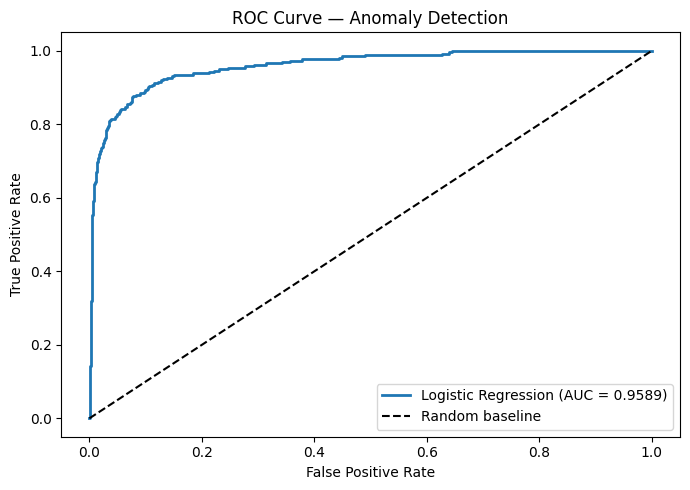

In [18]:
fpr, tpr, thresholds = roc_curve(y, y_scores_cv)
auc = roc_auc_score(y, y_scores_cv)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc:.4f})", lw=2)
plt.plot([0, 1], [0, 1], "k--", label="Random baseline")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Anomaly Detection")
plt.legend()
plt.tight_layout()
plt.show()

## Precision-Recall Curve

C:\Users\ChunChunMaru\AppData\Local\Temp\ipykernel_14252\2852331049.py:47: RuntimeWarning: invalid value encountered in divide
  2


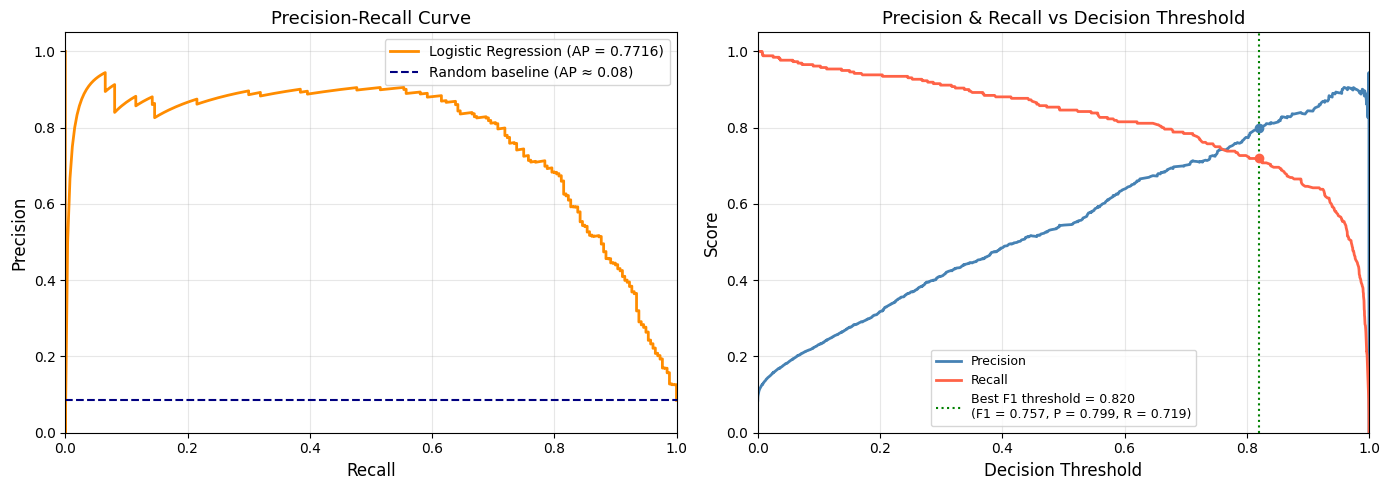

Average Precision (AP)  : 0.7716
Random baseline AP      : 0.0850  (= anomaly prevalence)
Improvement over random : 9.1x

Best F1 threshold : 0.820
  Precision       : 0.7991
  Recall          : 0.7192
  F1              : 0.7571


In [19]:
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    PrecisionRecallDisplay,
)

# ── Compute PR curve from cross-validated scores ────────────────────────────
# y_scores_cv and y must already exist from the logistic regression notebook
precision_vals, recall_vals, thresholds = precision_recall_curve(y, y_scores_cv)
ap = average_precision_score(y, y_scores_cv)
baseline = y.mean()  # a random classifier sits at this precision level

# ── Plot ────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# --- Left: full PR curve ---
ax = axes[0]
ax.plot(
    recall_vals,
    precision_vals,
    lw=2,
    color="darkorange",
    label=f"Logistic Regression (AP = {ap:.4f})",
)
ax.axhline(
    baseline,
    color="navy",
    linestyle="--",
    label=f"Random baseline (AP ≈ {baseline:.2f})",
)
ax.set_xlabel("Recall", fontsize=12)
ax.set_ylabel("Precision", fontsize=12)
ax.set_title("Precision-Recall Curve", fontsize=13)
ax.set_xlim([0, 1])
ax.set_ylim([0, 1.05])
ax.legend(fontsize=10)
ax.grid(alpha=0.3)

# --- Right: Precision & Recall vs Threshold ---
ax2 = axes[1]
ax2.plot(thresholds, precision_vals[:-1], lw=2, color="steelblue", label="Precision")
ax2.plot(thresholds, recall_vals[:-1], lw=2, color="tomato", label="Recall")

# Mark F1-optimal threshold
f1_scores = np.where(
    (precision_vals[:-1] + recall_vals[:-1]) > 0,
    2
    * precision_vals[:-1]
    * recall_vals[:-1]
    / (precision_vals[:-1] + recall_vals[:-1]),
    0,
)
best_idx = np.argmax(f1_scores)
best_thresh = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

ax2.axvline(
    best_thresh,
    color="green",
    linestyle=":",
    lw=1.5,
    label=f"Best F1 threshold = {best_thresh:.3f}\n(F1 = {best_f1:.3f}, "
    f"P = {precision_vals[best_idx]:.3f}, R = {recall_vals[best_idx]:.3f})",
)
ax2.scatter([best_thresh], [precision_vals[best_idx]], color="steelblue", zorder=5)
ax2.scatter([best_thresh], [recall_vals[best_idx]], color="tomato", zorder=5)

ax2.set_xlabel("Decision Threshold", fontsize=12)
ax2.set_ylabel("Score", fontsize=12)
ax2.set_title("Precision & Recall vs Decision Threshold", fontsize=13)
ax2.set_xlim([0, 1])
ax2.set_ylim([0, 1.05])
ax2.legend(fontsize=9)
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"Average Precision (AP)  : {ap:.4f}")
print(f"Random baseline AP      : {baseline:.4f}  (= anomaly prevalence)")
print(f"Improvement over random : {ap / baseline:.1f}x")
print()
print(f"Best F1 threshold : {best_thresh:.3f}")
print(f"  Precision       : {precision_vals[best_idx]:.4f}")
print(f"  Recall          : {recall_vals[best_idx]:.4f}")
print(f"  F1              : {best_f1:.4f}")

In [20]:
# ── Sample the curve at fixed recall levels ─────────────────────────────────
sample_recalls = np.linspace(0, 1, 11)  # 0.0, 0.1, ..., 1.0

rows = []
for target_r in sample_recalls:
    # Find index where recall is closest to the target
    idx = np.argmin(np.abs(recall_vals - target_r))
    thresh = thresholds[idx] if idx < len(thresholds) else 1.0
    rows.append(
        {
            "Recall (target)": f"{target_r:.1f}",
            "Recall (actual)": f"{recall_vals[idx]:.4f}",
            "Precision": f"{precision_vals[idx]:.4f}",
            "Threshold": f"{thresh:.4f}",
        }
    )

pr_table = pd.DataFrame(rows)
print(pr_table.to_string(index=False))

Recall (target) Recall (actual) Precision Threshold
            0.0          0.0000    0.0000    1.0000
            0.1          0.1000    0.8667    0.9993
            0.2          0.2000    0.8667    0.9969
            0.3          0.3000    0.8864    0.9930
            0.4          0.4000    0.8889    0.9867
            0.5          0.5000    0.9028    0.9709
            0.6          0.6000    0.8814    0.9385
            0.7          0.7000    0.8125    0.8391
            0.8          0.8000    0.6820    0.6619
            0.9          0.9000    0.4398    0.3379
            1.0          1.0000    0.0850    0.0000


In [24]:
# ── Export Performance Results to Excel (append mode) ────────────────────────
import os, openpyxl
from datetime import datetime
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side
from openpyxl.utils import get_column_letter
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    classification_report,
)

EXCEL_PATH = "performance_results.xlsx"

# ── Styles ───────────────────────────────────────────────────────────────────
HEADER_FILL = PatternFill("solid", start_color="1F4E79", end_color="1F4E79")
SECTION_FILL = PatternFill("solid", start_color="BDD7EE", end_color="BDD7EE")
ALT_FILL = PatternFill("solid", start_color="DEEAF1", end_color="DEEAF1")
RUN_FILL = PatternFill("solid", start_color="E2EFDA", end_color="E2EFDA")
HEADER_FONT = Font(name="Arial", bold=True, color="FFFFFF", size=11)
SECTION_FONT = Font(name="Arial", bold=True, color="1F4E79", size=10)
RUN_FONT = Font(name="Arial", bold=True, color="375623", size=10)
BODY_FONT = Font(name="Arial", size=10)
CENTER = Alignment(horizontal="center", vertical="center")
LEFT = Alignment(horizontal="left", vertical="center")
thin = Side(style="thin", color="9DC3E6")
BORDER = Border(left=thin, right=thin, top=thin, bottom=thin)


def style_header(cell, text):
    cell.value = text
    cell.font = HEADER_FONT
    cell.fill = HEADER_FILL
    cell.alignment = CENTER
    cell.border = BORDER


def style_section(cell, text):
    cell.value = text
    cell.font = SECTION_FONT
    cell.fill = SECTION_FILL
    cell.alignment = LEFT
    cell.border = BORDER


def style_body(cell, value, alt=False, num_fmt="0.0000"):
    cell.value = value
    cell.font = BODY_FONT
    cell.fill = ALT_FILL if alt else PatternFill(fill_type=None)
    cell.alignment = CENTER
    cell.border = BORDER
    if isinstance(value, float):
        cell.number_format = num_fmt


def style_run_header(cell, text):
    cell.value = text
    cell.font = RUN_FONT
    cell.fill = RUN_FILL
    cell.alignment = LEFT
    cell.border = BORDER


def set_col_widths(ws, widths):
    for i, w in enumerate(widths, 1):
        ws.column_dimensions[get_column_letter(i)].width = w


def next_append_row(ws):
    """First empty row after existing content, with one blank gap."""
    return (ws.max_row + 2) if ws.max_row > 0 else 1


# ── Timestamp & config ───────────────────────────────────────────────────────
run_ts = datetime.now().strftime("%Y-%m-%d %H:%M:%S")
lr_C = float(pipeline.named_steps["lr"].C)
run_label_short = f"Run {{run_num}}"  # filled below once run_num known

# ── Load or create workbook ───────────────────────────────────────────────────
if os.path.exists(EXCEL_PATH):
    wb = openpyxl.load_workbook(EXCEL_PATH)
else:
    wb = openpyxl.Workbook()
    wb.remove(wb.active)

existing_cv = [s for s in wb.sheetnames if s == "CV Performance"]
run_num = 1
if "CV Performance" in wb.sheetnames:
    ws_check = wb["CV Performance"]
    # count data rows (skip header row 1)
    run_num = (
        sum(
            1
            for row in ws_check.iter_rows(min_row=2, max_col=1)
            if row[0].value is not None
        )
        + 1
    )

run_header_text = (
    f"Run {run_num}  |  {run_ts}  " f"|  C={lr_C}  |  SVD components={N_COMPONENTS}"
)

# ── Recompute metrics ─────────────────────────────────────────────────────────
auc_val = roc_auc_score(y, y_scores_cv)
prec_val = precision_score(y, y_pred_cv)
rec_val = recall_score(y, y_pred_cv)
f1_val = f1_score(y, y_pred_cv)
report = classification_report(
    y, y_pred_cv, target_names=["Normal", "Anomaly"], output_dict=True
)
precision_vals, recall_vals, pr_thresholds = precision_recall_curve(y, y_scores_cv)
ap = average_precision_score(y, y_scores_cv)
baseline = float(y.mean())
f1_scores_pr = np.where(
    (precision_vals[:-1] + recall_vals[:-1]) > 0,
    2
    * precision_vals[:-1]
    * recall_vals[:-1]
    / (precision_vals[:-1] + recall_vals[:-1]),
    0,
)
best_pr_idx = int(np.argmax(f1_scores_pr))
best_thresh = float(pr_thresholds[best_pr_idx])
best_f1_pr = float(f1_scores_pr[best_pr_idx])

# ════════════════════════════════════════════════════════════════════════════
# SHEET 1 — CV Performance  (flat comparison table, one row per run)
# ════════════════════════════════════════════════════════════════════════════
CV_COLS = [
    ("Run", 8, "0", lambda: run_num),
    ("Timestamp", 22, "@", lambda: run_ts),
    ("C (regularisation)", 20, "0.####", lambda: lr_C),
    ("SVD Components", 16, "0", lambda: N_COMPONENTS),
    ("AUC", 10, "0.0000", lambda: auc_val),
    ("Precision @0.5", 14, "0.0000", lambda: prec_val),
    ("Recall @0.5", 13, "0.0000", lambda: rec_val),
    ("F1 @0.5", 10, "0.0000", lambda: f1_val),
    ("AP (PR curve)", 14, "0.0000", lambda: ap),
    ("Best-F1 Threshold", 18, "0.0000", lambda: best_thresh),
    ("Best-F1 Score", 14, "0.0000", lambda: best_f1_pr),
    ("Normal Precision", 16, "0.0000", lambda: report["Normal"]["precision"]),
    ("Normal Recall", 14, "0.0000", lambda: report["Normal"]["recall"]),
    ("Anomaly Precision", 17, "0.0000", lambda: report["Anomaly"]["precision"]),
    ("Anomaly Recall", 15, "0.0000", lambda: report["Anomaly"]["recall"]),
    ("Macro Avg Precision", 19, "0.0000", lambda: report["macro avg"]["precision"]),
    ("Macro Avg Recall", 17, "0.0000", lambda: report["macro avg"]["recall"]),
    ("Description", 40, "@", lambda: RUN_DESC),
]

if "CV Performance" in wb.sheetnames:
    ws1 = wb["CV Performance"]
    data_row = ws1.max_row + 1
else:
    ws1 = wb.create_sheet("CV Performance")
    data_row = 2

# Always (re)write headers in row 1 — ensures all columns are labelled
for col_i, (label, width, _, _fn) in enumerate(CV_COLS, 1):
    style_header(ws1.cell(1, col_i), label)
    ws1.column_dimensions[get_column_letter(col_i)].width = width
ws1.row_dimensions[1].height = 20

alt = run_num % 2 == 0
for col_i, (_label, _w, fmt, fn) in enumerate(CV_COLS, 1):
    style_body(ws1.cell(data_row, col_i), fn(), alt, num_fmt=fmt)

# ════════════════════════════════════════════════════════════════════════════
# SHEET 2 — ROC Curve  (stacked blocks, one per run)
# ════════════════════════════════════════════════════════════════════════════
ROC_COLS = [
    ("False Positive Rate", 22),
    ("True Positive Rate", 22),
    ("Threshold", 18),
    ("Notes", 36),
]

if "ROC Curve" in wb.sheetnames:
    ws2 = wb["ROC Curve"]
    r2 = next_append_row(ws2)
else:
    ws2 = wb.create_sheet("ROC Curve")
    for col_i, (_, w) in enumerate(ROC_COLS, 1):
        ws2.column_dimensions[get_column_letter(col_i)].width = w
    r2 = 1

ws2.merge_cells(f"A{r2}:D{r2}")
style_run_header(ws2.cell(r2, 1), run_header_text)
ws2.row_dimensions[r2].height = 18
for col_i, (label, _) in enumerate(ROC_COLS, 1):
    style_header(ws2.cell(r2 + 1, col_i), label)

n_points = min(len(fpr), 100)
roc_idx = np.round(np.linspace(0, len(fpr) - 1, n_points)).astype(int)
thresh_s = np.append(thresholds, np.nan)[roc_idx]

for offset, (fp, tp, th) in enumerate(zip(fpr[roc_idx], tpr[roc_idx], thresh_s)):
    ri = r2 + 2 + offset
    alt = offset % 2 == 1
    style_body(ws2.cell(ri, 1), float(fp), alt)
    style_body(ws2.cell(ri, 2), float(tp), alt)
    style_body(ws2.cell(ri, 3), None if np.isnan(th) else float(th), alt)
    note = f"AUC={auc_val:.4f} — origin point (no threshold)" if offset == 0 else ""
    style_body(ws2.cell(ri, 4), note, alt, num_fmt="@")

# ════════════════════════════════════════════════════════════════════════════
# SHEET 3 — Precision-Recall Curve  (stacked blocks, one per run)
# ════════════════════════════════════════════════════════════════════════════
PR_COLS = [
    ("Recall", 16),
    ("Precision", 14),
    ("Threshold", 14),
    ("F1 Score", 12),
]

if "Precision-Recall Curve" in wb.sheetnames:
    ws3 = wb["Precision-Recall Curve"]
    r3 = next_append_row(ws3)
else:
    ws3 = wb.create_sheet("Precision-Recall Curve")
    for col_i, (_, w) in enumerate(PR_COLS, 1):
        ws3.column_dimensions[get_column_letter(col_i)].width = w
    r3 = 1

# Run header
ws3.merge_cells(f"A{r3}:D{r3}")
style_run_header(ws3.cell(r3, 1), run_header_text)
ws3.row_dimensions[r3].height = 18

# Summary line
ws3.merge_cells(f"A{r3+1}:D{r3+1}")
c_sum = ws3.cell(r3 + 1, 1)
c_sum.value = (
    f"AP={ap:.4f}  |  Baseline≈{baseline:.4f}  |  "
    f"Improvement {ap/baseline:.1f}x  |  "
    f"Best-F1 threshold={best_thresh:.3f} "
    f"(F1={best_f1_pr:.4f}, "
    f"P={precision_vals[best_pr_idx]:.4f}, "
    f"R={recall_vals[best_pr_idx]:.4f})"
)
c_sum.font = Font(name="Arial", size=9)
c_sum.alignment = Alignment(horizontal="left", vertical="center", wrap_text=True)
ws3.row_dimensions[r3 + 1].height = 26

# Section A: Sampled table
SEC_A_COLS = [
    ("Recall (target)", 16),
    ("Recall (actual)", 16),
    ("Precision", 14),
    ("Threshold", 14),
]
ws3.merge_cells(f"A{r3+2}:D{r3+2}")
style_section(ws3.cell(r3 + 2, 1), "Sampled PR Table — fixed recall levels 0.0 to 1.0")
for col_i, (label, _) in enumerate(SEC_A_COLS, 1):
    style_header(ws3.cell(r3 + 3, col_i), label)

for s_off, target_r in enumerate(np.linspace(0, 1, 11)):
    idx2 = int(np.argmin(np.abs(recall_vals - target_r)))
    th2 = float(pr_thresholds[idx2]) if idx2 < len(pr_thresholds) else 1.0
    row_i = r3 + 4 + s_off
    alt = s_off % 2 == 1
    style_body(ws3.cell(row_i, 1), float(target_r), alt)
    style_body(ws3.cell(row_i, 2), float(recall_vals[idx2]), alt)
    style_body(ws3.cell(row_i, 3), float(precision_vals[idx2]), alt)
    style_body(ws3.cell(row_i, 4), th2, alt)

# Section B: Full curve (downsampled)
sb = r3 + 16
ws3.merge_cells(f"A{sb}:D{sb}")
style_section(ws3.cell(sb, 1), "Full PR Curve — downsampled to 100 points")
for col_i, (label, _) in enumerate(PR_COLS, 1):
    style_header(ws3.cell(sb + 1, col_i), label)

n_pts = min(len(precision_vals) - 1, 100)
pr_idx = np.round(np.linspace(0, len(precision_vals) - 2, n_pts)).astype(int)
for p_off, pi in enumerate(pr_idx):
    ri = sb + 2 + p_off
    alt = p_off % 2 == 1
    denom = precision_vals[pi] + recall_vals[pi]
    f1v = float(2 * precision_vals[pi] * recall_vals[pi] / denom) if denom > 0 else 0.0
    style_body(ws3.cell(ri, 1), float(recall_vals[pi]), alt)
    style_body(ws3.cell(ri, 2), float(precision_vals[pi]), alt)
    style_body(ws3.cell(ri, 3), float(pr_thresholds[pi]), alt)
    style_body(ws3.cell(ri, 4), f1v, alt)

# ── Save ─────────────────────────────────────────────────────────────────────
wb.save(EXCEL_PATH)
print(f"{EXCEL_PATH} updated — Run {run_num} appended ({run_ts})")

C:\Users\ChunChunMaru\AppData\Local\Temp\ipykernel_14252\1684089038.py:116: RuntimeWarning: invalid value encountered in divide
  2


performance_results.xlsx updated — Run 1 appended (2026-03-30 14:57:53)


## 6. Anomaly Score Distribution

A well-trained model should separate the score distributions of normal vs anomalous users.

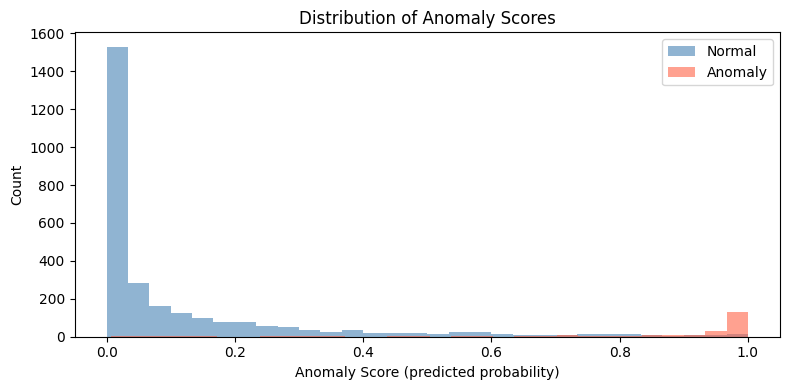

In [25]:
plt.figure(figsize=(8, 4))
plt.hist(y_scores_cv[y == 0], bins=30, alpha=0.6, label="Normal", color="steelblue")
plt.hist(y_scores_cv[y == 1], bins=30, alpha=0.6, label="Anomaly", color="tomato")
plt.xlabel("Anomaly Score (predicted probability)")
plt.ylabel("Count")
plt.title("Distribution of Anomaly Scores")
plt.legend()
plt.tight_layout()
plt.show()

## 7. Train Final Model & Generate Submission

We refit on the full training set, then score the held-out test batch.

In [26]:
# -- Fit final model on ALL training data ------------------------------------
# Uses the best pipeline variant selected in model-cv (baseline LR, LR+IF,
# or LR+BorderlineSMOTE+IF) and its corresponding feature matrix.
# Also fits the tuned best_pipeline from hyperparameter-tuning if available.

if "best_pipeline_cv" in dir() and best_pipeline_cv is not None:
    _use_pipeline = best_pipeline_cv
    _use_X = X_best
    print("Fitting best CV pipeline on full training set ...")
elif "best_pipeline" in dir() and best_pipeline is not None:
    _use_pipeline = best_pipeline
    _use_X = X_raw_combined
    print("Fitting hyperparameter-tuned pipeline on full training set ...")
else:
    _use_pipeline = pipeline
    _use_X = X_raw_combined
    print("Fitting default pipeline on full training set ...")

_use_pipeline.fit(_use_X, y)
pipeline.fit(X_raw_combined, y)  # always keep baseline fitted as fallback
print("Done.")

Fitting best CV pipeline on full training set ...


Done.


In [30]:
# -- Helper: build test features matching the training pipeline exactly -----
#
# ROOT CAUSE OF THE ValueError:
#   SVDPlusHandcrafted.transform() slices X[:, :-N_HANDCRAFTED] to get the
#   user-item block. N_HANDCRAFTED is the number of columns in agg at the
#   time dim-reduction ran. After feature-engineering added DegSim,
#   cosine_sim_to_normal, and mahal_dist directly to agg, N_HANDCRAFTED grew.
#   But build_features_raw only called compute_handcrafted_features(), which
#   does NOT append those three cross-population columns — so X_test_combined
#   had fewer columns than training and the SVD slice was wrong.
#
# FIX: build_features_raw now appends all columns in exactly the same order
#   as feature-engineering does, using the training artefacts that are already
#   in memory (_ui_pearson, mean_normal_vec, lw).

from sklearn.metrics.pairwise import cosine_similarity as _cs_fn
from sklearn.preprocessing import normalize as _nfn_gs


def build_features_raw(X_interactions, all_items, recon_svd):
    """
    Build a feature matrix for any interaction batch that exactly matches
    the column layout seen by the pipeline at training time:
      [user-item pivot (aligned to training items)] +
      [compute_handcrafted_features columns]        +
      [degsim_pearson]                              +
      [top5_corating_overlap]                       +
      [cosine_sim_to_normal]                        +
      [mahal_dist]

    Uses all training artefacts from memory:
      _ui_pearson      — Pearson-normalised training user-item matrix
      mean_normal_vec  — centroid of normal training users
      lw               — fitted LedoitWolf covariance estimator
    """
    df = pd.DataFrame(X_interactions, columns=["user", "item", "rating"])

    # Align pivot to TRAINING item columns (fills unseen items with 0)
    pivot = (
        df.pivot_table(index="user", columns="item", values="rating", aggfunc="mean")
        .reindex(columns=all_items, fill_value=0)
        .fillna(0)
    )

    # Reconstruction error using TRAINING SVD
    _approx = recon_svd.transform(pivot.values) @ recon_svd.components_
    recon_err = pd.Series(
        np.mean((pivot.values - _approx) ** 2, axis=1),
        index=pivot.index,
        name="recon_error",
    )

    # Handcrafted features (RDMA, WDMA, WDA, LengthVar, FMD, FMTD, MeanVar, etc.)
    agg_new = compute_handcrafted_features(df, recon_error=recon_err).loc[pivot.index]

    # -- DegSim (Pearson): test users vs TRAINING population -----------------
    # Mean-centre the test pivot, L2-normalise, dot with training Pearson matrix
    _DEGSIM_K_gs = 20
    _te_centered = pivot.values - pivot.values.mean(axis=1, keepdims=True)
    _te_pearson = _nfn_gs(_te_centered, norm="l2")
    _sim_te_tr = _te_pearson @ _ui_pearson.T  # (n_test, n_train)
    _degsim_test = np.sort(_sim_te_tr, axis=1)[:, -_DEGSIM_K_gs:].mean(axis=1)
    agg_new["degsim_pearson"] = (
        pd.Series(_degsim_test, index=pivot.index).reindex(agg_new.index).fillna(0)
    )

    # -- Co-rating overlap: test users vs TRAINING population ----------------
    _te_binary = (pivot.values > 0).astype(np.float32)
    _te_bin_norm = _nfn_gs(_te_binary, norm="l2")
    _tr_binary = (user_item.values > 0).astype(np.float32)
    _tr_bin_norm = _nfn_gs(_tr_binary, norm="l2")
    _overlap_te = _te_bin_norm @ _tr_bin_norm.T  # (n_test, n_train)
    _top5_test = np.sort(_overlap_te, axis=1)[:, -5:].mean(axis=1)
    agg_new["top5_corating_overlap"] = (
        pd.Series(_top5_test, index=pivot.index).reindex(agg_new.index).fillna(0)
    )

    # -- Cosine similarity to TRAINING normal centroid -----------------------
    _cos_test = _cs_fn(pivot.values, mean_normal_vec).ravel()
    agg_new["cosine_sim_to_normal"] = (
        pd.Series(_cos_test, index=pivot.index).reindex(agg_new.index).fillna(0)
    )

    # -- Mahalanobis distance using TRAINING LedoitWolf covariance -----------
    _mahal_test = np.sqrt(lw.mahalanobis(agg_new.values))
    agg_new["mahal_dist"] = (
        pd.Series(_mahal_test, index=agg_new.index).reindex(agg_new.index).fillna(0)
    )

    return np.hstack([pivot.values, agg_new.values]), pivot.index.tolist()


# -- Score the test batch ----------------------------------------------------
data_test = np.load(os.path.join(data_folder, "third_batch.npz"))
X_test_raw = data_test["X"]

all_items = user_item.columns.tolist()  # training item index

X_test_combined, test_users = build_features_raw(X_test_raw, all_items, _recon_svd)

# Sanity check — must match training width exactly
assert X_test_combined.shape[1] == X_raw_combined.shape[1], (
    f"Column mismatch: test={X_test_combined.shape[1]}, "
    f"train={X_raw_combined.shape[1]}. "
    f"Check that feature-engineering and build_features_raw add the same columns."
)
print(
    f"Feature matrix shape — train: {X_raw_combined.shape}  test: {X_test_combined.shape}"
)

score_pipeline = (
    best_pipeline
    if "best_pipeline" in dir() and best_pipeline is not None
    else pipeline
)
anomaly_scores = score_pipeline.predict_proba(X_test_combined)[:, 1]

print(f"Scored {len(anomaly_scores)} users")
print(f"Score range  : [{anomaly_scores.min():.4f}, {anomaly_scores.max():.4f}]")
print(f"Mean score   : {anomaly_scores.mean():.4f}")

np.savez("submission_lr.npz", predictions=anomaly_scores)
print("\nsubmission_lr.npz saved!")

Feature matrix shape — train: (3060, 1026)  test: (1625, 1026)
Scored 1625 users
Score range  : [0.0000, 0.9984]
Mean score   : 0.1200

submission_lr.npz saved!


In [31]:
from zipfile import ZipFile, ZIP_DEFLATED
import shutil

# Timestamped names
ts = datetime.now().strftime("%Y%m%d_%H%M%S")
src_npz = "submission_lr.npz"

if not os.path.exists(src_npz):
    raise FileNotFoundError(f"{src_npz} not found. Run the submission-generation cell first.")

# Save timestamped npz and zip into results directory
npz_name = f"submission_lr_{ts}.npz"
zip_name = f"submission_lr_{ts}.zip"

npz_path = os.path.join(RESULTS_DIR_LARRY, npz_name)
zip_path = os.path.join(RESULTS_DIR_LARRY, zip_name)

shutil.copy2(src_npz, npz_path)

with ZipFile(zip_path, "w", compression=ZIP_DEFLATED) as zf:
    zf.write(npz_path, arcname=npz_name)

print(f"Saved NPZ: {npz_path}")
print(f"Saved ZIP: {zip_path}")

Saved NPZ: c:\Users\ChunChunMaru\Desktop\SMU schoolwork\cs421pain\Strategies/Larry/results\Logreg_exp3\submission_lr_20260330_151415.npz
Saved ZIP: c:\Users\ChunChunMaru\Desktop\SMU schoolwork\cs421pain\Strategies/Larry/results\Logreg_exp3\submission_lr_20260330_151415.zip


## 8. (Optional) Hyperparameter Tuning

Run this cell to search over regularisation strength `C` and SVD components. This can meaningfully improve AUC.

In [28]:
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import precision_recall_curve as _prc_tune


# ==========================================================================
# Custom best-F1 scorer (threshold-free)
#
# sklearn's built-in "f1" scorer calls predict() at the default 0.5 threshold
# — wrong for 10:1 imbalanced data where the optimum is ~0.3-0.4.
# This callable scorer calls predict_proba(), sweeps the full PR curve, and
# returns the MAXIMUM F1 achievable at any threshold for that fold.
# Pass directly as scoring=best_f1_scorer — do NOT wrap with make_scorer().
# ==========================================================================
def best_f1_scorer(estimator, X, y_true):
    probs = estimator.predict_proba(X)[:, 1]
    pr, re, _ = _prc_tune(y_true, probs)
    denom = pr[:-1] + re[:-1]
    f1v = np.where(denom > 0, 2 * pr[:-1] * re[:-1] / np.maximum(denom, 1e-12), 0.0)
    return float(np.max(f1v))


_skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ==========================================================================
# Grid 1 — L2 regularisation (lbfgs solver)
#
# Searches n_components, C, and class_weight jointly.
# "balanced" auto-computes ~10:1 from the class ratio; explicit weights
# sweep the nearby space to find whether the optimum is slightly above
# or below that.
# ==========================================================================
print("=" * 60)
print("Grid 1  L2 regularisation (lbfgs)")
print("=" * 60)

_pipe_l2 = Pipeline(
    [
        ("svd_hc", SVDPlusHandcrafted(n_components=30)),
        ("scaler", StandardScaler()),
        ("lr", LogisticRegression(solver="lbfgs", max_iter=1000, random_state=42)),
    ]
)

param_grid_l2 = {
    "svd_hc__n_components": [40, 60, 80, 100, 120],
    "lr__C": [0.01, 0.05, 0.1, 0.5],
    "lr__class_weight": [
        "balanced",
        {0: 1, 1: 8},
        {0: 1, 1: 10},
        {0: 1, 1: 12},
        {0: 1, 1: 15},
    ],
}

grid_l2 = GridSearchCV(
    _pipe_l2,
    param_grid_l2,
    scoring=best_f1_scorer,
    cv=_skf,
    n_jobs=-1,
    verbose=0,
    refit=True,
)
grid_l2.fit(X_raw_combined, y)

print(f"Best n_components : {grid_l2.best_params_['svd_hc__n_components']}")
print(f"Best C            : {grid_l2.best_params_['lr__C']}")
print(f"Best class_weight : {grid_l2.best_params_['lr__class_weight']}")
print(f"Best CV F1        : {grid_l2.best_score_:.4f}")

# Top 5 results
_res_l2 = pd.DataFrame(grid_l2.cv_results_)
print(
    _res_l2[
        [
            "param_svd_hc__n_components",
            "param_lr__C",
            "param_lr__class_weight",
            "mean_test_score",
        ]
    ]
    .sort_values("mean_test_score", ascending=False)
    .head(5)
    .to_string(index=False)
)


# ==========================================================================
# Grid 2 — ElasticNet regularisation (saga solver)
#
# WHY ElasticNet / L1 on top of L2:
# After SVD the feature matrix has 40-120 embedding dimensions of varying
# quality, plus ~14 handcrafted columns. L2 shrinks ALL coefficients equally
# — it cannot zero out weak SVD dimensions. L1 / ElasticNet CAN set
# coefficients exactly to zero, performing implicit feature selection inside
# the LR. This is valuable when some SVD components capture noise rather
# than shilling-attack signal.
#
# l1_ratio controls the mix:
#   l1_ratio = 1.0  → pure L1 (maximum sparsity, strongest selection)
#   l1_ratio = 0.5  → balanced ElasticNet
#   l1_ratio = 0.1  → mostly L2 with mild sparsity
#
# The saga solver is required for ElasticNet; it converges well on
# StandardScaler-normalised features (approximate same scale).
# max_iter=2000 because saga needs more iterations than lbfgs.
# ==========================================================================
print("\n" + "=" * 60)
print("Grid 2  ElasticNet regularisation (saga)")
print("=" * 60)

_pipe_en = Pipeline(
    [
        ("svd_hc", SVDPlusHandcrafted(n_components=30)),
        ("scaler", StandardScaler()),
        (
            "lr",
            LogisticRegression(
                solver="saga",
                penalty="elasticnet",
                max_iter=2000,
                random_state=42,
            ),
        ),
    ]
)

param_grid_en = {
    "svd_hc__n_components": [40, 60, 80, 100, 120],
    "lr__C": [0.01, 0.05, 0.1, 0.5],
    "lr__l1_ratio": [0.1, 0.5, 0.9, 1.0],
    "lr__class_weight": [
        "balanced",
        {0: 1, 1: 10},
        {0: 1, 1: 12},
        {0: 1, 1: 15},
    ],
}

grid_en = GridSearchCV(
    _pipe_en,
    param_grid_en,
    scoring=best_f1_scorer,
    cv=_skf,
    n_jobs=-1,
    verbose=0,
    refit=True,
)
grid_en.fit(X_raw_combined, y)

print(f"Best n_components : {grid_en.best_params_['svd_hc__n_components']}")
print(f"Best C            : {grid_en.best_params_['lr__C']}")
print(f"Best l1_ratio     : {grid_en.best_params_['lr__l1_ratio']}")
print(f"Best class_weight : {grid_en.best_params_['lr__class_weight']}")
print(f"Best CV F1        : {grid_en.best_score_:.4f}")

_res_en = pd.DataFrame(grid_en.cv_results_)
print(
    _res_en[
        [
            "param_svd_hc__n_components",
            "param_lr__C",
            "param_lr__l1_ratio",
            "param_lr__class_weight",
            "mean_test_score",
        ]
    ]
    .sort_values("mean_test_score", ascending=False)
    .head(5)
    .to_string(index=False)
)


# ==========================================================================
# Select winner and evaluate with per-fold threshold averaging
# ==========================================================================
print("\n" + "=" * 60)
print("Summary")
print("=" * 60)
print(f"L2  best CV F1 : {grid_l2.best_score_:.4f}")
print(f"EN  best CV F1 : {grid_en.best_score_:.4f}")

if grid_en.best_score_ >= grid_l2.best_score_:
    best_pipeline = grid_en.best_estimator_
    _winner = "ElasticNet (saga)"
    _winner_score = grid_en.best_score_
else:
    best_pipeline = grid_l2.best_estimator_
    _winner = "L2 (lbfgs)"
    _winner_score = grid_l2.best_score_

print(f"Winner: {_winner}  (CV F1 = {_winner_score:.4f})")

# Evaluate winner with per-fold threshold averaging
y_scores_best = cross_val_predict(
    best_pipeline,
    X_raw_combined,
    y,
    cv=_skf,
    method="predict_proba",
)[:, 1]

_best_thresholds = []
for _tr_idx, _val_idx in _skf.split(X_raw_combined, y):
    _c = best_pipeline
    _c.fit(X_raw_combined[_tr_idx], y[_tr_idx])
    _pr_b, _re_b, _th_b = _prc_tune(
        y[_val_idx], _c.predict_proba(X_raw_combined[_val_idx])[:, 1]
    )
    _d = _pr_b[:-1] + _re_b[:-1]
    _f = np.where(_d > 0, 2 * _pr_b[:-1] * _re_b[:-1] / np.maximum(_d, 1e-12), 0.0)
    if len(_th_b) > 0:
        _best_thresholds.append(float(_th_b[np.argmax(_f)]))

best_f1_threshold_tuned = float(np.mean(_best_thresholds)) if _best_thresholds else 0.5
y_pred_best = (y_scores_best >= best_f1_threshold_tuned).astype(int)

print(f"\n=== Tuned {_winner} — cross-validated ===")
print(
    f"AUC       : {roc_auc_score(y, y_scores_best):.4f}  "
    f"(baseline: {roc_auc_score(y, y_scores_cv):.4f})"
)
print(
    f"F1 thresh : {best_f1_threshold_tuned:.4f}  "
    f"(per-fold: {[f'{t:.3f}' for t in _best_thresholds]})"
)
print(f"Precision : {precision_score(y, y_pred_best):.4f}")
print(f"Recall    : {recall_score(y, y_pred_best):.4f}")
print(
    f"F1        : {f1_score(y, y_pred_best):.4f}  "
    f"(baseline: {f1_score(y, y_pred_cv):.4f})"
)
print()
print(classification_report(y, y_pred_best, target_names=["Normal", "Anomaly"]))

Grid 1  L2 regularisation (lbfgs)


Best n_components : 40
Best C            : 0.5
Best class_weight : {0: 1, 1: 10}
Best CV F1        : 0.7841
 param_svd_hc__n_components  param_lr__C param_lr__class_weight  mean_test_score
                         40          0.5          {0: 1, 1: 10}         0.784150
                         40          0.5           {0: 1, 1: 8}         0.783518
                         40          0.5          {0: 1, 1: 15}         0.780959
                         40          0.5               balanced         0.779937
                         40          0.1           {0: 1, 1: 8}         0.779724

Grid 2  ElasticNet regularisation (saga)


KeyboardInterrupt: 